In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [42]:
df = pd.read_csv("../data/Telco_Customer_Churn.csv")
df.shape

(7043, 21)

# Predict churn to retain customers
**Each row is a customer**
### Main columns:
- Services used by the customer
- Churn: customers who left last month
- Customer account preferences: payment menthod, contract, etc...
- Demogaraphic about the customer: age, gender, family infos

In [43]:
df.head()
pd.set_option('display.max_columns', None) # show all columns
pd.set_option('display.max_rows', None) # show all rows

In [44]:
df.describe(include='all')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Convert binary variables to 0/1
## Convert 2+ categories variables with One Hot Encoding

In [25]:
binary_cols = ["gender","Partner","Dependents","PhoneService","PaperlessBilling","Churn"]
df[binary_cols] = df[binary_cols].replace({'Yes':1, 'No':0, 'Male':1,'Female':0})

multicat_cols = ["MultipleLines","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection",
                 "TechSupport","StreamingTV","StreamingMovies","Contract","PaymentMethod"]
df = pd.get_dummies(df, columns=multicat_cols, drop_first=True)


/var/folders/yb/vbtzq9693hq7ytp6nmv278d00000gn/T/ipykernel_76724/4201567921.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({'Yes':1, 'No':0, 'Male':1,'Female':0})


In [20]:
# Convert TotalCharges to numeric and make sure empty values are treated as NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
# Drop Customer ID, not relevant for modeling
df = df.drop('customerID', axis=1)

# Turn booleans to integers
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


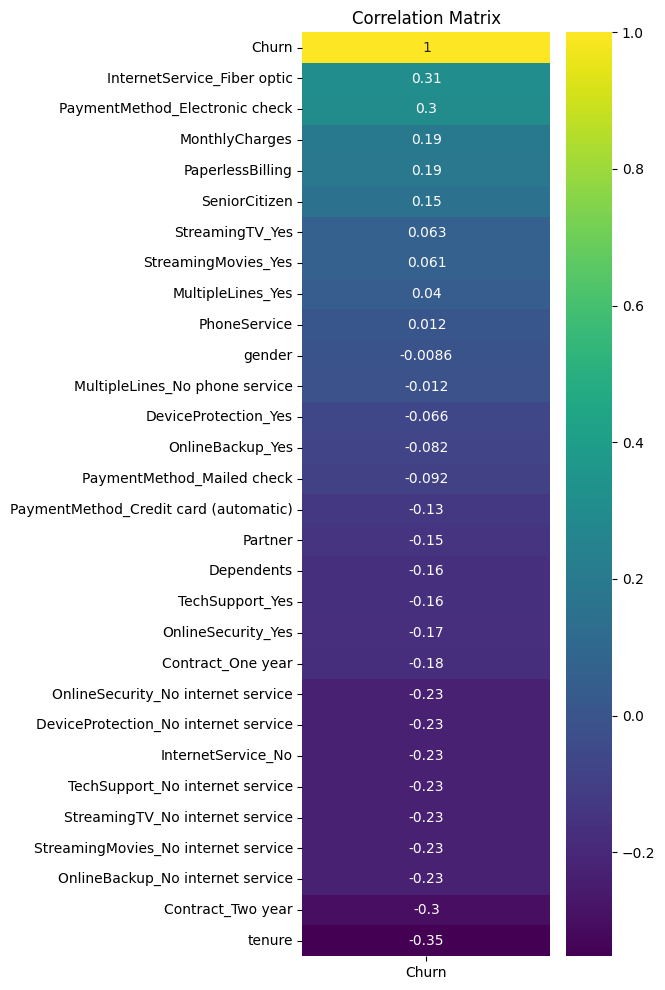

In [ ]:
corr_matrix = df.corr(numeric_only=True)
churn_corr = corr_matrix["Churn"].sort_values(ascending=False)
churn_corr_df = pd.DataFrame(churn_corr)
plt.figure(figsize=(4,12))
sns.heatmap(churn_corr_df, annot=True, cmap='viridis')
plt.title("Correlation Matrix")
plt.show()

# We can see the columns that highly correlate with churn

In [ ]:
# After seeing the correlation matrix, we want to know if there
# are multicollinearity issues for the columns that correlate with churn

# Redundant columns that indicate no internet service
df['No_internet_service'] = (
    df['OnlineSecurity_No internet service'] |
    df['OnlineBackup_No internet service'] |
    df['DeviceProtection_No internet service'] |
    df['TechSupport_No internet service'] |
    df['StreamingTV_No internet service'] |
    df['StreamingMovies_No internet service']
).astype(int)

# Drop former dummies columns
drop_cols = [col for col in df.columns if 'No internet service' in col]
df = df.drop(columns=drop_cols, axis=1)

if 'MultipleLines_No phone service' in df.columns:
    df['No_phone_service'] = df['MultipleLines_No phone service'].astype(int)
    df = df.drop(columns=['MultipleLines_No phone service'], axis=1)


In [ ]:
X = df.drop(columns=['Churn'])
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)